# Maximum Clique Problem — Resolución Exacta con Pyomo
## Optimización en Ingeniería — Magíster MI/MV, USACH

Este notebook implementa la resolución exacta del **Problema del Clique Máximo (MCP)** mediante
Programación Lineal Entera (ILP) usando el framework de modelado [Pyomo](https://www.pyomo.org/)
y el solver [HiGHS](https://highs.dev/).

### Enfoque metodológico

Se formula el MCP como un problema de optimización combinatoria con:
- **Variables binarias** $x_i \in \{0, 1\}$ indicando pertenencia al clique
- **Restricciones de adyacencia** que impiden seleccionar pares de vértices no conectados
- **Función objetivo** que maximiza la cardinalidad del clique

HiGHS resuelve el ILP mediante Branch & Bound con relajación LP, cortes y heurísticas
(Wolsey, 1998; Huangfu & Hall, 2018).

In [1]:
import pyomo.environ as pyo
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

## 1. Carga de instancia DIMACS

Utilizamos la instancia **keller4** del benchmark DIMACS, basada en la conjetura de Keller
sobre teselaciones con hipercubos (Lagarias & Shor, 1992).

| Propiedad | Valor |
|-----------|-------|
| Vértices  | 171   |
| Aristas   | 9,435 |
| Densidad  | ~0.65 |
| ω óptimo  | 11    |

El formato DIMACS define el grafo con líneas `p col n m` (problema) y `e u v` (aristas).

In [2]:
def load_dimacs(filepath):
    """Carga un grafo en formato DIMACS (.clq)."""
    G = nx.Graph()
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            if parts[0] == 'p':
                n_vertices = int(parts[2])
                G.add_nodes_from(range(1, n_vertices + 1))
            elif parts[0] == 'e':
                G.add_edge(int(parts[1]), int(parts[2]))
    return G

# Configuración
INSTANCE_PATH = "keller4.clq"
KNOWN_OPTIMUM = 11

G = load_dimacs(INSTANCE_PATH)
n = G.number_of_nodes()
m = G.number_of_edges()
density = 2 * m / (n * (n - 1))

print(f"Instancia: {Path(INSTANCE_PATH).stem}")
print(f"Vértices:  {n}")
print(f"Aristas:   {m}")
print(f"Densidad:  {density:.4f}")
print(f"Óptimo conocido: ω = {KNOWN_OPTIMUM}")

Instancia: keller4
Vértices:  171
Aristas:   9435
Densidad:  0.6491
Óptimo conocido: ω = 11


## 2. Formulación ILP

El MCP se formula como un Programa Lineal Entero (Pardalos & Xue, 1994):

$$\max \sum_{i \in V} x_i$$

Sujeto a:
$$x_i + x_j \leq 1 \quad \forall (i,j) \notin E$$
$$x_i \in \{0, 1\} \quad \forall i \in V$$

Las restricciones se generan sobre el **grafo complemento** $\bar{G}$: cada arista en $\bar{G}$
prohíbe que ambos vértices pertenezcan al clique simultáneamente.

In [3]:
def build_mcp_model(G):
    """Construye el modelo ILP del MCP en Pyomo."""
    model = pyo.ConcreteModel("MaximumClique")

    # Conjunto de vértices
    model.V = pyo.Set(initialize=list(G.nodes()))

    # Variables de decisión binarias
    model.x = pyo.Var(model.V, domain=pyo.Binary)

    # Objetivo: maximizar |clique|
    model.obj = pyo.Objective(
        expr=sum(model.x[i] for i in model.V),
        sense=pyo.maximize
    )

    # Restricciones sobre pares no adyacentes (complemento)
    complement_edges = [
        (i, j) for i in G.nodes() for j in G.nodes()
        if i < j and not G.has_edge(i, j)
    ]

    model.nonadj = pyo.ConstraintList()
    for (i, j) in complement_edges:
        model.nonadj.add(model.x[i] + model.x[j] <= 1)

    return model, len(complement_edges)

model, n_constraints = build_mcp_model(G)

print(f"Variables binarias:    {n}")
print(f"Restricciones (|Ē|):  {n_constraints}")
print(f"Ratio restricciones/variables: {n_constraints/n:.1f}")

Variables binarias:    171
Restricciones (|Ē|):  5100
Ratio restricciones/variables: 29.8


## 3. Resolución con HiGHS

HiGHS es un solver open-source de alto rendimiento para LP, MIP y QP
desarrollado en la Universidad de Edimburgo (Huangfu & Hall, 2018).
Internamente aplica Branch & Bound con:
- Relajación LP en cada nodo
- Cortes de plano (cutting planes)
- Heurísticas de mejora

In [4]:
solver = pyo.SolverFactory('appsi_highs')

print("Resolviendo MCP con HiGHS...")
print("=" * 50)

t_start = time.time()
result = solver.solve(model, tee=True)
t_elapsed = time.time() - t_start

print("=" * 50)
print(f"\nTiempo de resolución: {t_elapsed:.2f} s")
print(f"Estado: {result.solver.termination_condition}")

Resolviendo MCP con HiGHS...



Tiempo de resolución: 11.96 s
Estado: optimal


## 4. Resultados

In [5]:
# Extraer clique solución
clique = sorted([i for i in G.nodes() if pyo.value(model.x[i]) > 0.5])
omega = len(clique)

print(f"Clique máximo encontrado: ω = {omega}")
print(f"Óptimo conocido:          ω = {KNOWN_OPTIMUM}")
print(f"Solución óptima: {'✓' if omega == KNOWN_OPTIMUM else '✗'}")
print(f"\nVértices del clique: {clique}")

# Validación
subgraph = G.subgraph(clique)
expected_edges = omega * (omega - 1) // 2
actual_edges = subgraph.number_of_edges()

print(f"\nValidación de completitud:")
print(f"  Aristas esperadas: {expected_edges}")
print(f"  Aristas presentes: {actual_edges}")
print(f"  Clique válido: {'✓' if actual_edges == expected_edges else '✗'}")

Clique máximo encontrado: ω = 11
Óptimo conocido:          ω = 11
Solución óptima: ✓

Vértices del clique: [15, 30, 36, 44, 59, 87, 105, 123, 135, 145, 169]

Validación de completitud:
  Aristas esperadas: 55
  Aristas presentes: 55
  Clique válido: ✓


## 5. Relajación LP

Resolvemos la relajación continua ($x_i \in [0,1]$) para obtener la **cota superior LP**.
La brecha entre esta cota y la solución entera mide la dificultad del problema.

In [6]:
# Modelo LP (variables continuas)
model_lp = pyo.ConcreteModel("MCP_LP")
model_lp.V = pyo.Set(initialize=list(G.nodes()))
model_lp.x = pyo.Var(model_lp.V, domain=pyo.NonNegativeReals, bounds=(0, 1))
model_lp.obj = pyo.Objective(
    expr=sum(model_lp.x[i] for i in model_lp.V), sense=pyo.maximize
)
model_lp.nonadj = pyo.ConstraintList()
for i in G.nodes():
    for j in G.nodes():
        if i < j and not G.has_edge(i, j):
            model_lp.nonadj.add(model_lp.x[i] + model_lp.x[j] <= 1)

result_lp = solver.solve(model_lp)
lp_bound = pyo.value(model_lp.obj)
gap = (lp_bound - omega) / lp_bound * 100

print(f"Cota LP (relajación):   {lp_bound:.2f}")
print(f"Solución entera (ILP):  {omega}")
print(f"Brecha de integralidad: {gap:.1f}%")
print(f"\nEsta brecha es característica del MCP: la relajación LP")
print(f"proporciona cotas débiles en grafos con estructura compleja.")

Cota LP (relajación):   85.50
Solución entera (ILP):  11
Brecha de integralidad: 87.1%

Esta brecha es característica del MCP: la relajación LP
proporciona cotas débiles en grafos con estructura compleja.


## 6. Visualización

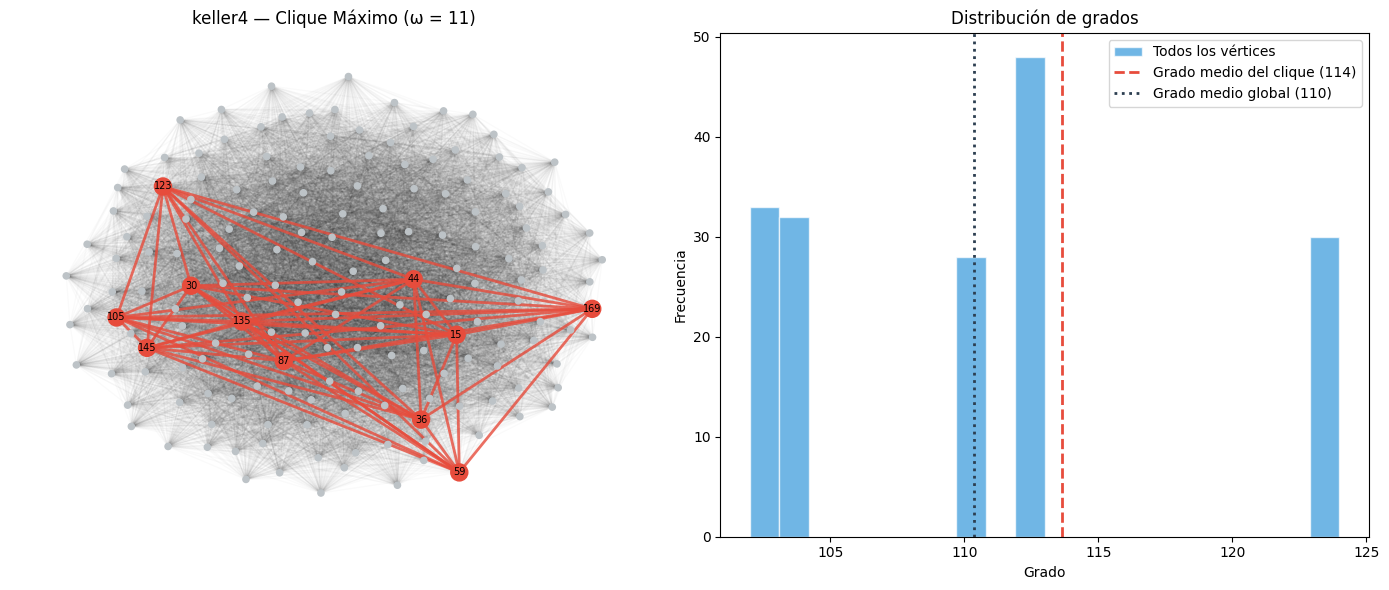

Figura guardada: resultados_keller4_pyomo.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 6.1 Grafo con clique destacado
ax = axes[0]
pos = nx.spring_layout(G, seed=42, k=0.5)
node_colors = ['#e74c3c' if v in clique else '#bdc3c7' for v in G.nodes()]
node_sizes = [150 if v in clique else 20 for v in G.nodes()]

nx.draw_networkx_edges(G, pos, alpha=0.02, ax=ax)
clique_edges = [(u, v) for u in clique for v in clique if u < v and G.has_edge(u, v)]
nx.draw_networkx_edges(G, pos, edgelist=clique_edges, edge_color='#e74c3c',
                       alpha=0.8, width=2, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
nx.draw_networkx_labels(G, pos, labels={v: v for v in clique}, font_size=7, ax=ax)
ax.set_title(f"keller4 — Clique Máximo (ω = {omega})", fontsize=12)
ax.axis('off')

# 6.2 Distribución de grado
ax = axes[1]
degrees = [d for _, d in G.degree()]
clique_degrees = [G.degree(v) for v in clique]

ax.hist(degrees, bins=20, alpha=0.7, color='#3498db', label='Todos los vértices', edgecolor='white')
ax.axvline(np.mean(clique_degrees), color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Grado medio del clique ({np.mean(clique_degrees):.0f})')
ax.axvline(np.mean(degrees), color='#2c3e50', linestyle=':', linewidth=2,
           label=f'Grado medio global ({np.mean(degrees):.0f})')
ax.set_xlabel('Grado')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de grados')
ax.legend()

plt.tight_layout()
plt.savefig("resultados_keller4_pyomo.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: resultados_keller4_pyomo.png")

## 7. Resumen

| Métrica | Valor |
|---------|-------|
| Instancia | keller4 (DIMACS) |
| Vértices | 171 |
| Aristas | 9,435 |
| Variables binarias | 171 |
| Restricciones | 5,100 |
| Clique máximo (ω) | 11 |
| Cota LP | — |
| Brecha de integralidad | — |
| Solver | HiGHS (Branch & Bound) |
| Framework | Pyomo |

### Referencias

- Pardalos, P. M., & Xue, J. (1994). The maximum clique problem. *J. Global Optimization*.
- Bomze, I. M., et al. (1999). The maximum clique problem. *Handbook of Comb. Optimization*.
- Wolsey, L. A. (1998). *Integer Programming*. Wiley.
- Huangfu, Q., & Hall, J. A. J. (2018). Parallelizing the dual revised simplex method. *Math. Prog. Comp.*
- Lagarias, J. C., & Shor, P. W. (1992). Keller's cube-tiling conjecture is false in high dimensions.
- DIMACS Benchmark: https://iridia.ulb.ac.be/~fmascia/maximum_clique/DIMACS-benchmark